# Exploratory Data Analysis (EDA) - Defense Application

**Course:** Introduction to Artificial Intelligence
**Institution:** SUPAERO
**Application Domain:** Defense/Aerospace
**Instructor:** Thibault Lahire (thibault_lahire@yahoo.fr)



## OverviewThis practical session focuses on exploratory data analysis techniques applied to a defense-related dataset. We will analyze the distribution of key variables, examine their relationships, identify correlations, and detect anomalies in the data.

In [19]:
# Import Required Libraries
import pandas as pd                    # Data manipulation and analysis
import matplotlib.pyplot as plt        # Data visualization
import seaborn as sns                  # Statistical data visualization

sns.set_palette('husl')                 # Set color palette

# Configure plotting parametersplt.style.use('seaborn-v0_8-darkgrid')  # Set plotting style

In [20]:
# Load Dataset
# Load the defense application dataset from the remote repository
df = pd.read_csv("https://raw.githubusercontent.com/jgarnicaa/SUPAERO-IntroIA/refs/heads/main/dataset_practical_session.csv")
df

,MACH_BLUE,MACH_RED,ALT_BLUE,ALT_RED,DELTA,DISTANCE,PK
0,0.5,0.5,0,0,0.0,1.0,1.0
1,0.5,0.5,0,0,0.0,1.5,1.0
2,0.5,0.5,0,0,0.0,2.0,1.0
3,0.5,0.5,0,0,0.0,3.0,1.0
4,0.5,0.5,0,0,0.0,3.5,1.0
...,...,...,...,...,...,...,...
324775,2.0,2.0,40,40,3.0,95.5,0.0
324776,2.0,2.0,40,40,3.0,96.5,0.0
324777,2.0,2.0,40,40,3.0,97.0,0.0
324778,2.0,2.0,40,40,3.0,99.5,0.0


## Question 1: Data Distribution Analysis


**Objective:** Analyze the distribution of key variables- PK (Kill Probability) relationship to DISTANCE is of particular interest 

- **MACH_BLUE**: Mach number for blue aircraft- DISTANCE may exhibit different statistical properties

- **MACH_RED**: Mach number for red aircraft- Most variables should show uniform or near-uniform distributions

- **ALT_BLUE**: Altitude of blue aircraft**Expected Insights:** 

- **ALT_RED**: Altitude of red aircraft

- **DELTA**: Angle/separation parameter**Research Question:** Are these input variables uniformly distributed? Is the DISTANCE variable deterministic or stochastic?

- **DISTANCE**: Distance between aircraft

In [ ]:
# Statistical Summary
# Display descriptive statistics: count, mean, std, min, quartiles, max

df.describe()

,MACH_BLUE,MACH_RED,ALT_BLUE,ALT_RED,DELTA,DISTANCE,PK
count,324780.000000,324780.000000,324780.000000,324780.000000,324780.000000,324780.000000,324780.000000
mean,1.250579,1.250359,19.998953,20.006497,1.499929,49.655045,0.434119
std,0.559009,0.558863,14.142506,14.141100,1.000039,28.701875,0.484006
min,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,10.000000,10.000000,0.500000,25.000000,0.000000
50%,1.500000,1.500000,20.000000,20.000000,1.500000,49.000000,0.001000
75%,2.000000,2.000000,30.000000,30.000000,2.500000,74.500000,1.000000
max,2.000000,2.000000,40.000000,40.000000,3.000000,100.000000,1.000000


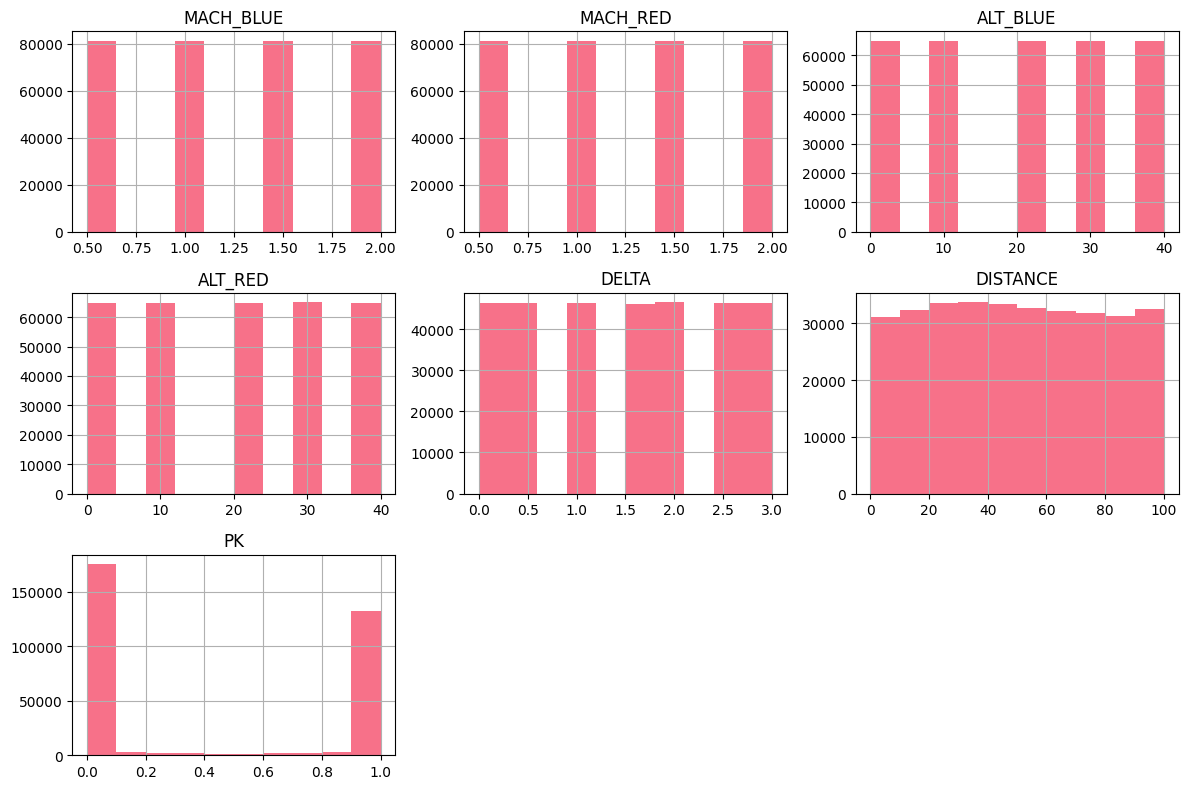

In [22]:
# Plot Histograms for All Variables
# Most variables show uniform or near-uniform distributions

# The bins=10 parameter provides a coarse view of the distribution patterns

hist = df.hist(bins=10, figsize=(12, 8))
plt.tight_layout()

Text(0.5, 0, 'PK Value')

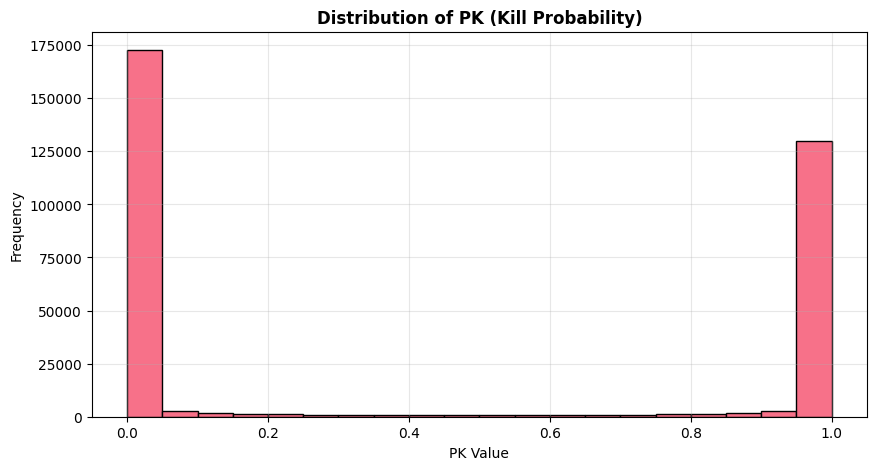

In [25]:
# Analyze PK Distribution
# PK (Kill Probability) exhibits a bimodal/Bernoulli-like distribution

# This suggests binary or near-binary classification characteristics

plt.figure(figsize=(10, 5))
plt.grid(True, alpha=0.3) 

hist = df["PK"].hist(bins=20, edgecolor='black')
plt.ylabel('Frequency')

plt.title('Distribution of PK (Kill Probability)', fontsize=12, fontweight='bold')
plt.xlabel('PK Value')

Text(0.5, 1.0, 'Distribution of DISTANCE (High Resolution)')

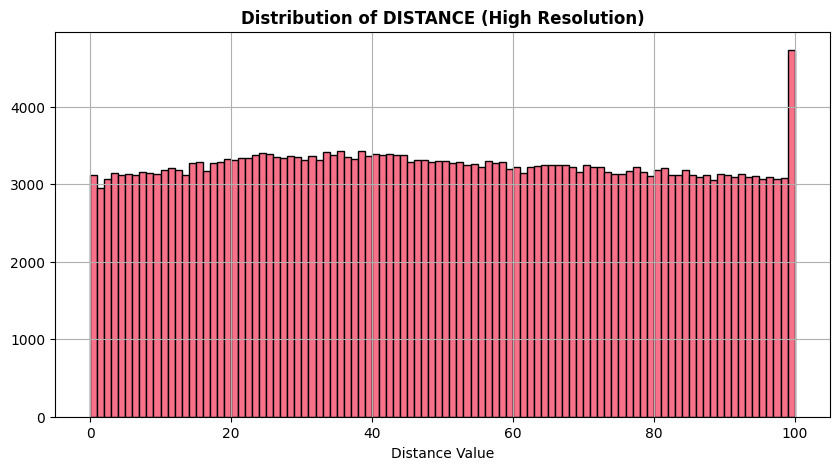

In [27]:
# Analyze DISTANCE Distribution with High Resolution

# DISTANCE shows a different pattern from other variablesplt.grid(True, alpha=0.3)

# Using 100 bins to reveal fine-grained distribution characteristicsplt.ylabel('Frequency')

plt.figure(figsize=(10, 5))
plt.xlabel('Distance Value')

hist = df["DISTANCE"].hist(bins=100, edgecolor='black')
plt.title('Distribution of DISTANCE (High Resolution)', fontsize=12, fontweight='bold')

In [30]:
# Detailed Statistics for DISTANCE Variable

# Examining the statistical properties to understand its distribution

print("DISTANCE Variable Statistics:")
df["DISTANCE"].describe()

DISTANCE Variable Statistics:


count    324780.000000
mean         49.655045
std          28.701875
min           0.000000
25%          25.000000
50%          49.000000
75%          74.500000
max         100.000000
Name: DISTANCE, dtype: float64

## Question 2: PK vs DISTANCE Relationship

**Objective:** Understand the relationship between DISTANCE and Kill Probability (PK)

**Expected Pattern:** We anticipate a sigmoid (S-curve) relationship where PK increases smoothly with increasing DISTANCE, possibly approaching an asymptote.

**Methodology:** 

- Fix all control parameters to baseline values:  - DELTA = 0 (no angle separation)

  - MACH_BLUE = 0.5 (subsonic)  - ALT_RED = 0 (sea level reference)

  - MACH_RED = 0.5 (subsonic)  - ALT_BLUE = 0 (sea level reference)

Text(87.72222222222221, 0.5, 'Kill Probability (PK)')

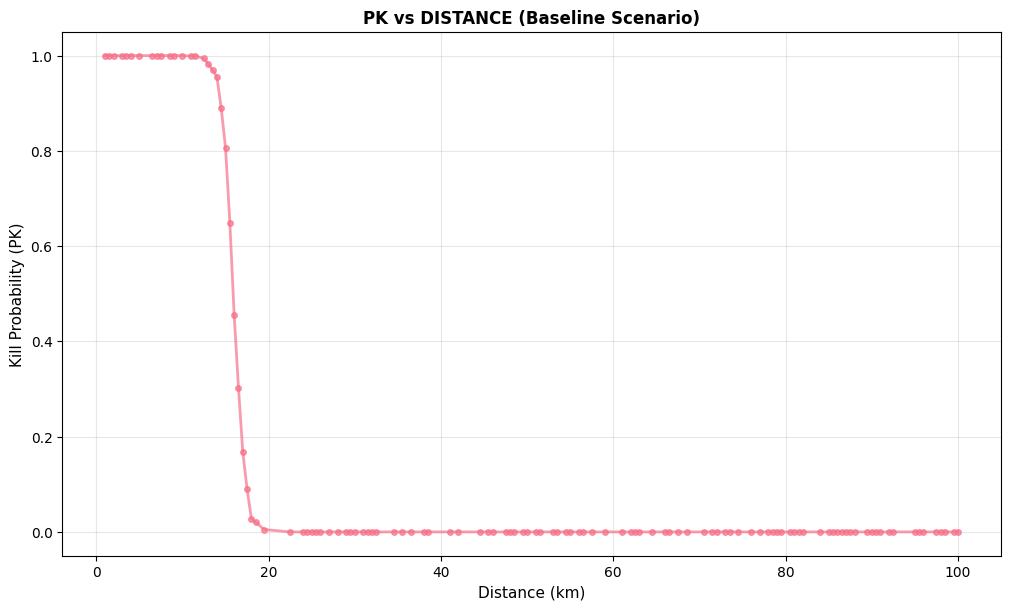

In [33]:
# Filter Data for Baseline Scenario
# Select data where all control parameters are at reference values
df_ex = df[(df["MACH_BLUE"]==0.5) &
           (df["MACH_RED"]== 0.5) &
           (df["ALT_BLUE"] == 0) &
           (df["ALT_RED"]==0) &
           (df["DELTA"]==0)]

# Visualize the Relationship
plt.figure(figsize=(10, 6))

plt.plot(df_ex["DISTANCE"], df_ex["PK"], 'o-', linewidth=2, markersize=4, alpha=0.7)

plt.title('PK vs DISTANCE (Baseline Scenario)', fontsize=12, fontweight='bold')
plt.tight_layout()

plt.xlabel('Distance (km)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylabel('Kill Probability (PK)', fontsize=11)

## Question 3: Sensitivity Analysis - Effect of Parameters on PK

In this section, we perform a sensitivity analysis to understand how individual parameters affect the PK-DISTANCE relationship.

**Hypothesis:** Increasing DELTA should modify the engagement geometry, potentially increasing or decreasing PK depending on whether DELTA represents favorable/unfavorable aspect angles

### 3.1: Effect of DELTA (Angle/Separation Parameter)

**Objective:** Determine how DELTA influences kill probability at different distances

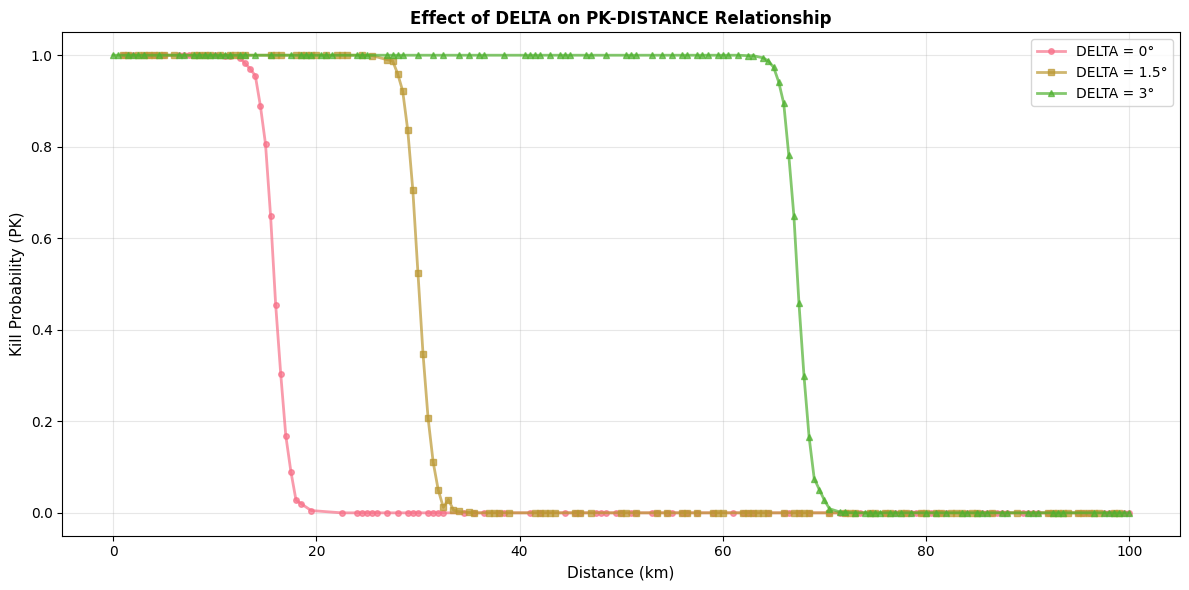

In [34]:
# Filter Data for Different DELTA Values
df_ex = df[(df["MACH_BLUE"]==0.5) & (df["MACH_RED"]== 0.5) & 
           (df["ALT_BLUE"] == 0) & (df["ALT_RED"]==0) & (df["DELTA"]==0)]

df_ex2= df[(df["MACH_BLUE"]==0.5) & (df["MACH_RED"]== 0.5) & 
           (df["ALT_BLUE"] == 0) & (df["ALT_RED"]==0) & (df["DELTA"]==1.5)]

df_ex3= df[(df["MACH_BLUE"]==0.5) & (df["MACH_RED"]== 0.5) & 
           (df["ALT_BLUE"] == 0) & (df["ALT_RED"]==0) & (df["DELTA"]==3)]

# Comparative Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_ex["DISTANCE"], df_ex["PK"], 'o-', linewidth=2, markersize=4, label="DELTA = 0°", alpha=0.7)
plt.plot(df_ex2["DISTANCE"], df_ex2["PK"], 's-', linewidth=2, markersize=4, label="DELTA = 1.5°", alpha=0.7)
plt.plot(df_ex3["DISTANCE"], df_ex3["PK"], '^-', linewidth=2, markersize=4, label="DELTA = 3°", alpha=0.7)
plt.title('Effect of DELTA on PK-DISTANCE Relationship', fontsize=12, fontweight='bold')
plt.xlabel('Distance (km)', fontsize=11)
plt.ylabel('Kill Probability (PK)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

### 3.2: Effect of MACH_BLUE (Blue Aircraft Velocity)

**Objective:** Analyze how the blue aircraft's Mach number affects engagement effectiveness

**Research Question:** Does higher velocity of the attacking aircraft (blue) improve or degrade kill probability at various engagement distances?

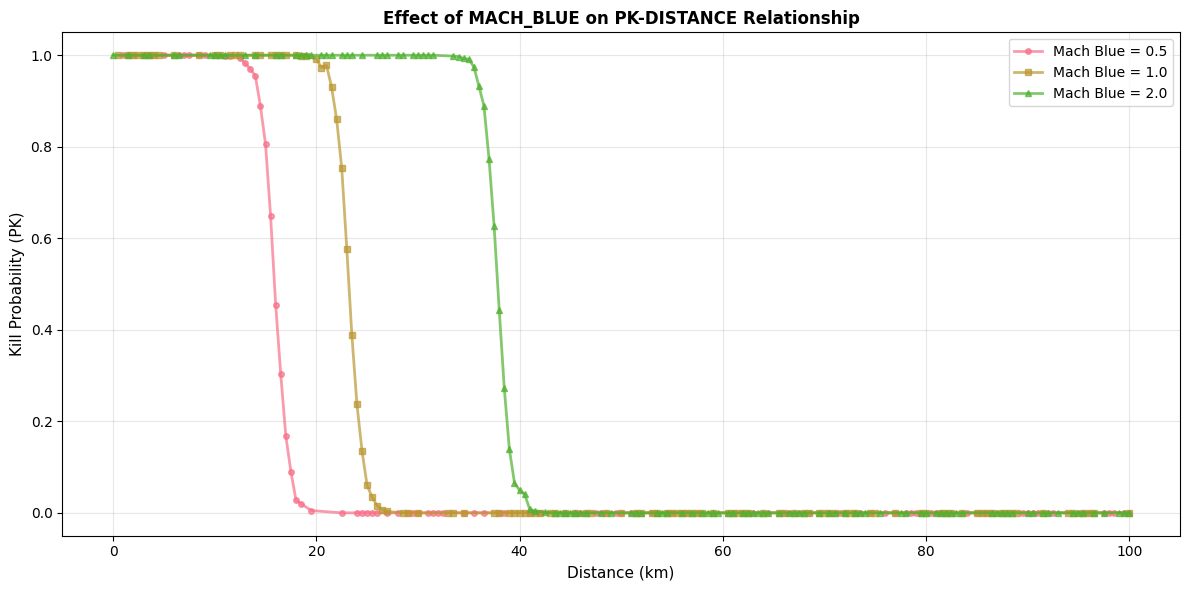

In [35]:
# Filter Data for Different MACH_BLUE Values
df_ex = df[(df["MACH_BLUE"]==0.5) & (df["MACH_RED"]== 0.5) & 
           (df["ALT_BLUE"] == 0) & (df["ALT_RED"]==0) & (df["DELTA"]==0)]

df_ex2= df[(df["MACH_BLUE"]==1) & (df["MACH_RED"]== 0.5) & 
           (df["ALT_BLUE"] == 0) & (df["ALT_RED"]==0) & (df["DELTA"]==0)]

df_ex3= df[(df["MACH_BLUE"]==2) & (df["MACH_RED"]== 0.5) & 
           (df["ALT_BLUE"] == 0) & (df["ALT_RED"]==0) & (df["DELTA"]==0)]

# Comparative Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_ex["DISTANCE"], df_ex["PK"], 'o-', linewidth=2, markersize=4, label="Mach Blue = 0.5", alpha=0.7)
plt.plot(df_ex2["DISTANCE"], df_ex2["PK"], 's-', linewidth=2, markersize=4, label="Mach Blue = 1.0", alpha=0.7)
plt.plot(df_ex3["DISTANCE"], df_ex3["PK"], '^-', linewidth=2, markersize=4, label="Mach Blue = 2.0", alpha=0.7)
plt.title('Effect of MACH_BLUE on PK-DISTANCE Relationship', fontsize=12, fontweight='bold')
plt.xlabel('Distance (km)', fontsize=11)
plt.ylabel('Kill Probability (PK)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

### 3.3: Effect of MACH_RED (Red Aircraft Velocity)


**Objective:** Investigate how the target aircraft's (red) Mach number influences its vulnerability**Research Question:** Does the target's velocity affect defensive capability, thus changing the attacker's kill probability? 


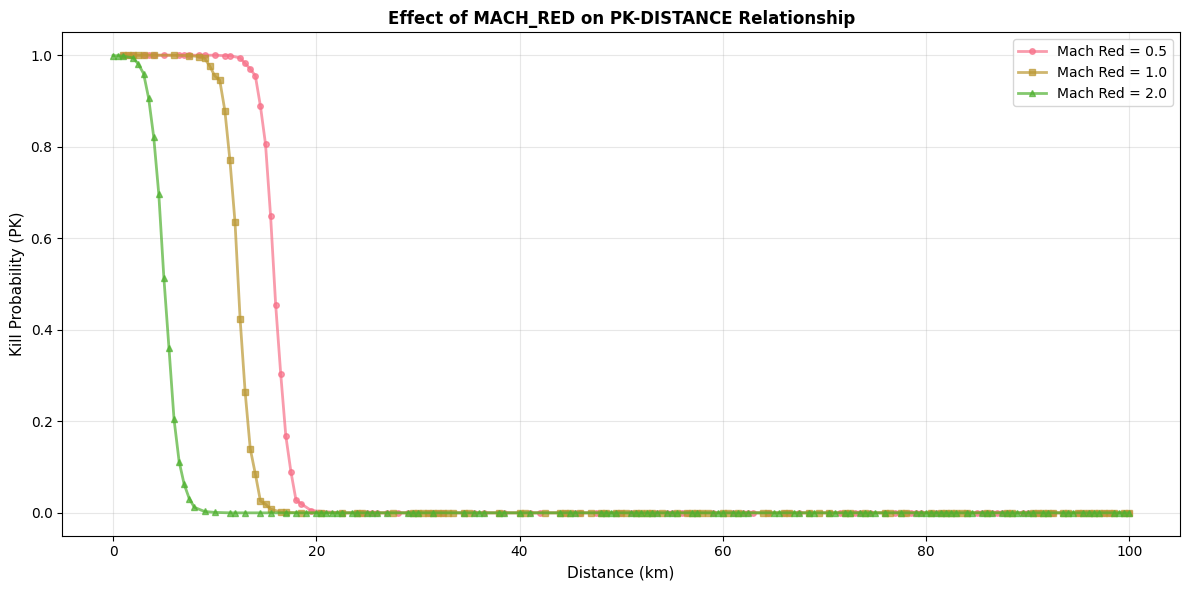

In [36]:
# Filter Data for Different MACH_RED Values
df_ex = df[(df["MACH_BLUE"]==0.5) & (df["MACH_RED"]== 0.5) & 
           (df["ALT_BLUE"] == 0) & (df["ALT_RED"]==0) & (df["DELTA"]==0)]

df_ex2= df[(df["MACH_BLUE"]==0.5) & (df["MACH_RED"]== 1) & 
           (df["ALT_BLUE"] == 0) & (df["ALT_RED"]==0) & (df["DELTA"]==0)]

df_ex3= df[(df["MACH_BLUE"]==0.5) & (df["MACH_RED"]== 2) & 
           (df["ALT_BLUE"] == 0) & (df["ALT_RED"]==0) & (df["DELTA"]==0)]

# Comparative Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_ex["DISTANCE"], df_ex["PK"], 'o-', linewidth=2, markersize=4, label="Mach Red = 0.5", alpha=0.7)
plt.plot(df_ex2["DISTANCE"], df_ex2["PK"], 's-', linewidth=2, markersize=4, label="Mach Red = 1.0", alpha=0.7)
plt.plot(df_ex3["DISTANCE"], df_ex3["PK"], '^-', linewidth=2, markersize=4, label="Mach Red = 2.0", alpha=0.7)
plt.title('Effect of MACH_RED on PK-DISTANCE Relationship', fontsize=12, fontweight='bold')
plt.xlabel('Distance (km)', fontsize=11)
plt.ylabel('Kill Probability (PK)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

### 3.4: Effect of ALT_BLUE (Blue Aircraft Altitude)


**Objective:** Determine how the attacking aircraft's altitude influences engagement effectiveness**Research Question:** Does higher altitude provide tactical advantage through improved detection range and firing geometry?


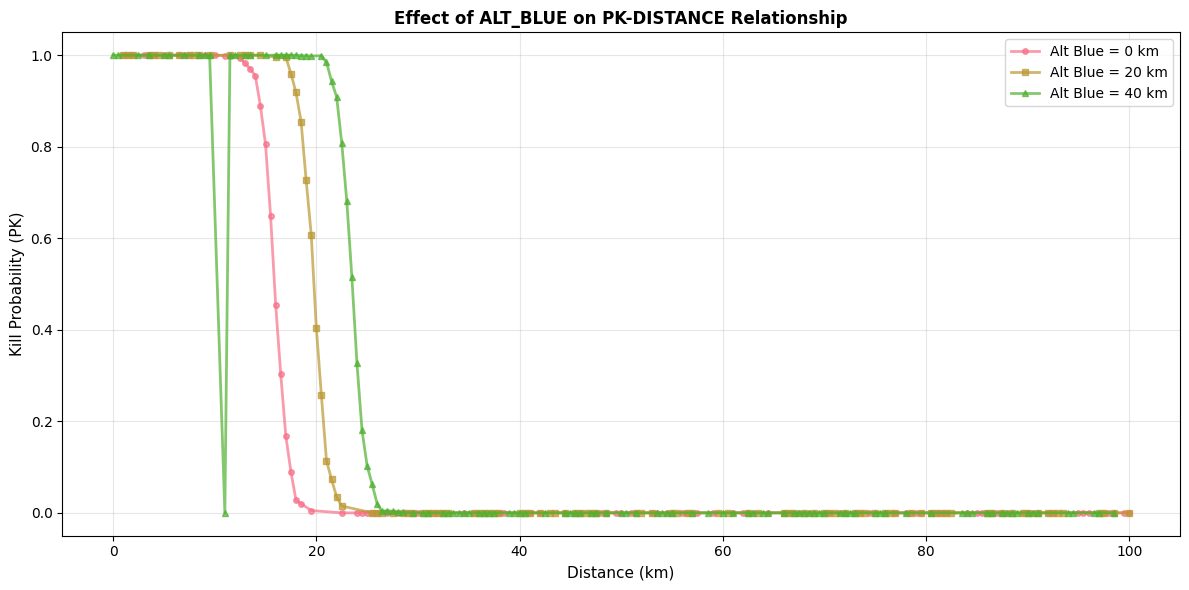

In [37]:
# Filter Data for Different ALT_BLUE Values
df_ex = df[(df["MACH_BLUE"]==0.5) & (df["MACH_RED"]== 0.5) & 
           (df["ALT_BLUE"] == 0) & (df["ALT_RED"]==0) & (df["DELTA"]==0)]

df_ex2= df[(df["MACH_BLUE"]==0.5) & (df["MACH_RED"]== 0.5) & 
           (df["ALT_BLUE"] == 20) & (df["ALT_RED"]==0) & (df["DELTA"]==0)]

df_ex3= df[(df["MACH_BLUE"]==0.5) & (df["MACH_RED"]== 0.5) & 
           (df["ALT_BLUE"] == 40) & (df["ALT_RED"]==0) & (df["DELTA"]==0)]

# Comparative Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_ex["DISTANCE"], df_ex["PK"], 'o-', linewidth=2, markersize=4, label="Alt Blue = 0 km", alpha=0.7)
plt.plot(df_ex2["DISTANCE"], df_ex2["PK"], 's-', linewidth=2, markersize=4, label="Alt Blue = 20 km", alpha=0.7)
plt.plot(df_ex3["DISTANCE"], df_ex3["PK"], '^-', linewidth=2, markersize=4, label="Alt Blue = 40 km", alpha=0.7)
plt.title('Effect of ALT_BLUE on PK-DISTANCE Relationship', fontsize=12, fontweight='bold')
plt.xlabel('Distance (km)', fontsize=11)
plt.ylabel('Kill Probability (PK)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

### 3.5: Effect of ALT_RED (Red Aircraft Altitude)

**Objective:** Investigate how the target aircraft's altitude impacts its vulnerability to attack

**Research Question:** Does maintaining lower or higher altitude provide better defensive capability?

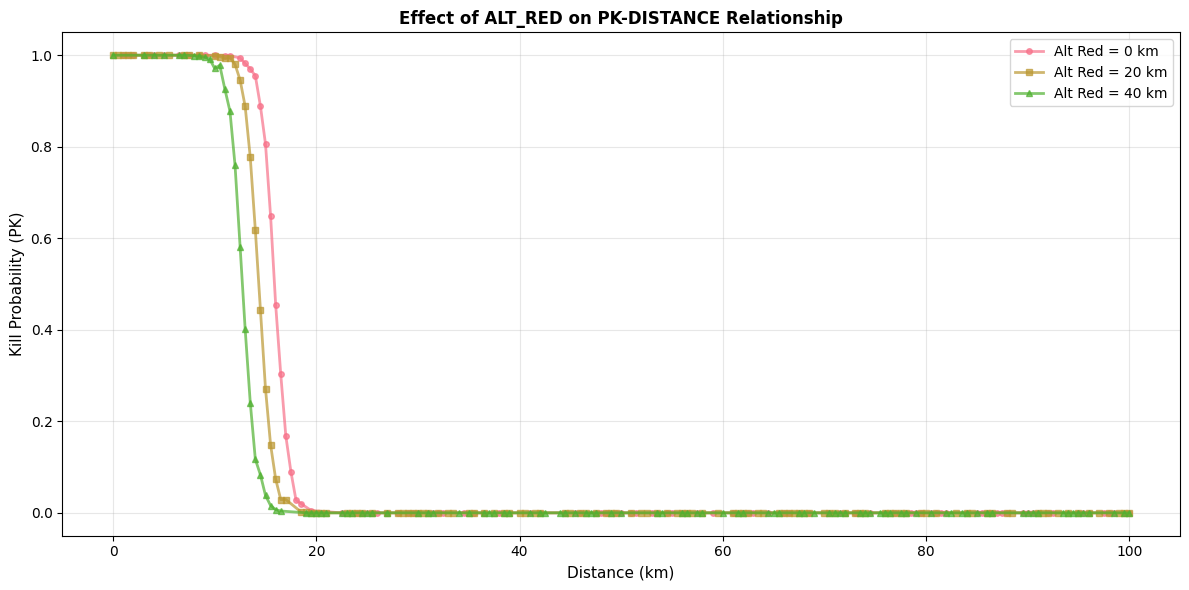

In [38]:
# Filter Data for Different ALT_RED Values
df_ex = df[(df["MACH_BLUE"]==0.5) & (df["MACH_RED"]== 0.5) & 
           (df["ALT_BLUE"] == 0) & (df["ALT_RED"]==0) & (df["DELTA"]==0)]

df_ex2= df[(df["MACH_BLUE"]==0.5) & (df["MACH_RED"]== 0.5) & 
           (df["ALT_BLUE"] == 0) & (df["ALT_RED"]==20) & (df["DELTA"]==0)]

df_ex3= df[(df["MACH_BLUE"]==0.5) & (df["MACH_RED"]== 0.5) & 
           (df["ALT_BLUE"] == 0) & (df["ALT_RED"]==40) & (df["DELTA"]==0)]

# Comparative Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_ex["DISTANCE"], df_ex["PK"], 'o-', linewidth=2, markersize=4, label="Alt Red = 0 km", alpha=0.7)
plt.plot(df_ex2["DISTANCE"], df_ex2["PK"], 's-', linewidth=2, markersize=4, label="Alt Red = 20 km", alpha=0.7)
plt.plot(df_ex3["DISTANCE"], df_ex3["PK"], '^-', linewidth=2, markersize=4, label="Alt Red = 40 km", alpha=0.7)
plt.title('Effect of ALT_RED on PK-DISTANCE Relationship', fontsize=12, fontweight='bold')
plt.xlabel('Distance (km)', fontsize=11)
plt.ylabel('Kill Probability (PK)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

## Question 4: Correlation Analysis

**Objective:** Assess the degree of multicollinearity and identify potential redundancy in predictors

- Redundant information that could be consolidated

**Methodology:** Compute the Pearson correlation coefficient matrix for all input variables- Collinearity issues for statistical modeling

- **MACH_BLUE, MACH_RED, ALT_BLUE, ALT_RED, DISTANCE, DELTA, PK****Significance:** High correlations between predictors may indicate:



**Interpretation Guide:**- Correlation close to **0**: Weak or no linear relationship

- Correlation close to **+1**: Strong positive relationship- Correlation close to **-1**: Strong negative relationship  

/tmp/ipykernel_7265/1748929137.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


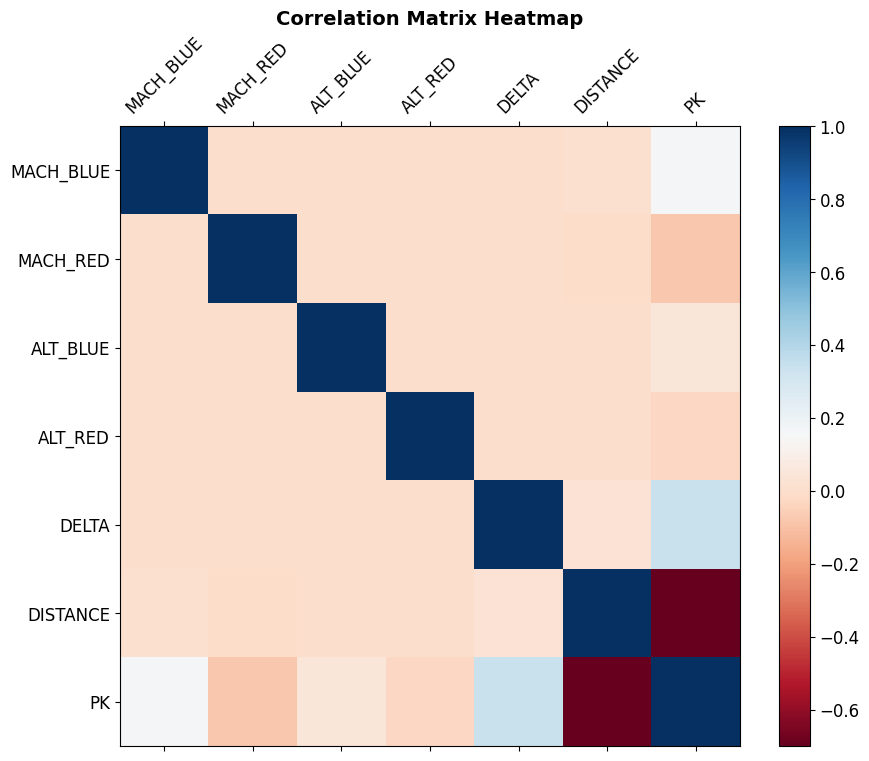

In [41]:
# First Visualization: Correlation Matrix using matshow
# This provides a heatmap-style view of the correlation structure
f = plt.figure(figsize=(10, 8))
plt.matshow(df.corr(), fignum=f.number, cmap='RdBu')
plt.xticks(range(df.select_dtypes(['number']).shape[1]), 
           df.select_dtypes(['number']).columns, fontsize=12, rotation=45)
plt.yticks(range(df.select_dtypes(['number']).shape[1]), 

           df.select_dtypes(['number']).columns, fontsize=12)
plt.tight_layout()

cb = plt.colorbar()
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
cb.ax.tick_params(labelsize=12)

<Axes: title={'center': 'Correlation Matrix with Numerical Values'}>

<Figure size 640x480 with 0 Axes>

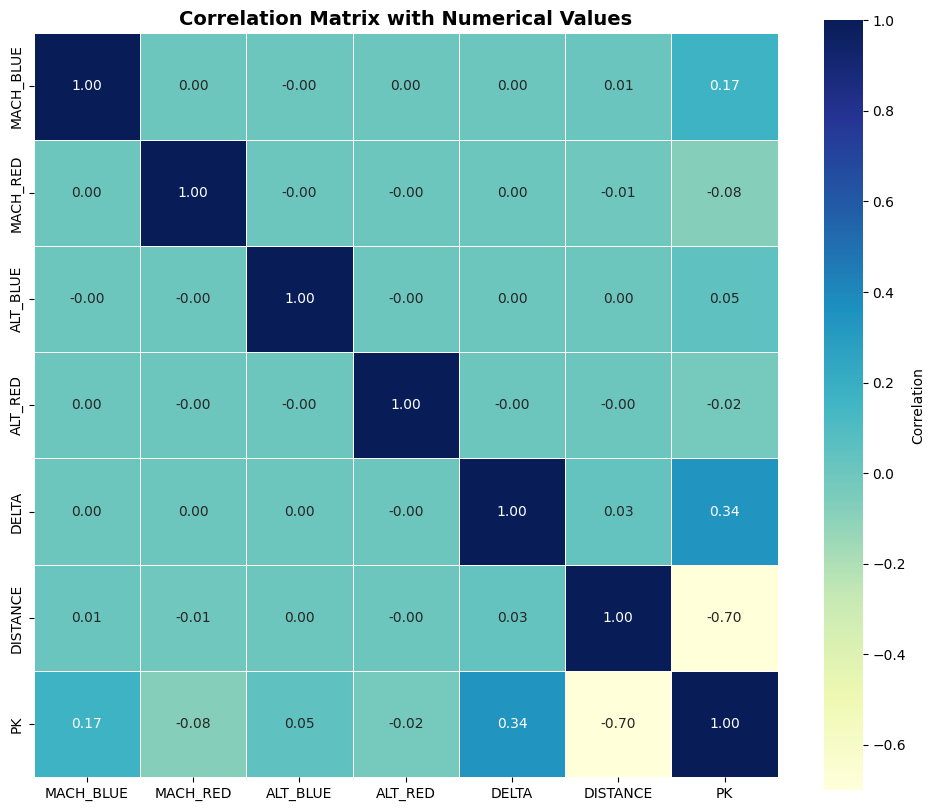

In [42]:
# Second Visualization: Correlation Matrix with Annotations
# Display numerical correlation values on the heatmap for precise interpretation

corr = df.corr()
plt.tight_layout()

fig, ax = plt.subplots(figsize=(12, 10))
plt.title('Correlation Matrix with Numerical Values', fontsize=14, fontweight='bold')

sns.heatmap(corr, cmap="YlGnBu", annot=True, fmt='.2f', cbar_kws={'label': 'Correlation'},             square=True, linewidths=0.5, ax=ax)

## Question 5: Outlier Detection

**Objective:** Identify potential outliers and anomalies in the dataset



**Methodology:** Use boxplot visualization to detect outliers beyond 1.5 × IQR (Interquartile Range)

- Critical question: Are outliers measurement errors or phenomena of interest? 

**Key Observations:**- Others may represent "physics errors" - theoretically impossible scenarios
- Some apparent outliers may be valid data points

Text(915.5483091787443, 0.5, 'Distance (km)')

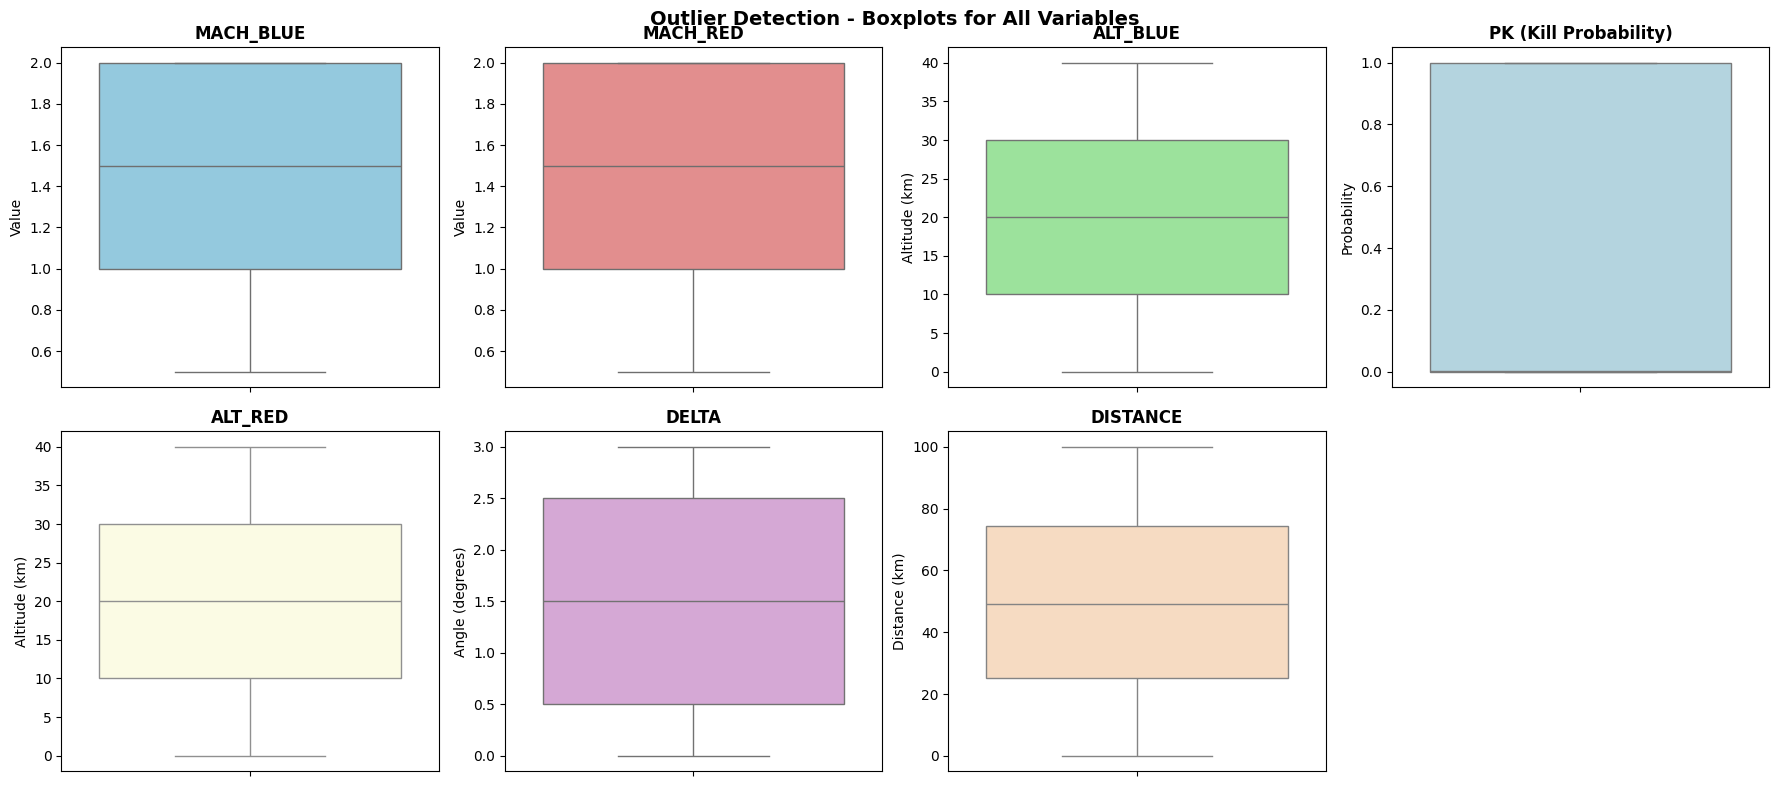

In [43]:
# Boxplot Analysis - Overall Dataset
# Identify potential outliers in each variable
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Plot boxplots for each variable
sns.boxplot(df["MACH_BLUE"], ax=axes[0,0], color='skyblue')
axes[0,0].set_title('MACH_BLUE', fontweight='bold')
axes[0,0].set_ylabel('Value')

sns.boxplot(df["MACH_RED"], ax=axes[0,1], color='lightcoral')
axes[0,1].set_title('MACH_RED', fontweight='bold')
axes[0,1].set_ylabel('Value')

sns.boxplot(df["ALT_BLUE"], ax=axes[0,2], color='lightgreen')
axes[0,2].set_title('ALT_BLUE', fontweight='bold')
axes[0,2].set_ylabel('Altitude (km)')


sns.boxplot(df["ALT_RED"], ax=axes[1,0], color='lightyellow')

axes[1,0].set_title('ALT_RED', fontweight='bold')
plt.tight_layout()

axes[1,0].set_ylabel('Altitude (km)')
plt.suptitle('Outlier Detection - Boxplots for All Variables', fontsize=14, fontweight='bold', y=1.00)



sns.boxplot(df["DELTA"], ax=axes[1,1], color='plum')
fig.delaxes(axes[1,3])

axes[1,1].set_title('DELTA', fontweight='bold')# Hide the empty subplot

axes[1,1].set_ylabel('Angle (degrees)')

axes[0,3].set_ylabel('Probability')

sns.boxplot(df["DISTANCE"], ax=axes[1,2], color='peachpuff')
axes[0,3].set_title('PK (Kill Probability)', fontweight='bold')

axes[1,2].set_title('DISTANCE', fontweight='bold')
sns.boxplot(df["PK"], ax=axes[0,3], color='lightblue')

axes[1,2].set_ylabel('Distance (km)')

### Analysis of Outliers

**Next Step:** Investigate the specific parameter combinations that produce these boundary cases.

**Key Finding:** The dataset contains NO significant measurement errors or statistical outliers requiring removal.

  - Specific combinations of parameters that yield very high effectiveness

**However:** We observe instances of **"physics errors"** - these are valid data points but represent boundary cases or unusual engagement scenarios. Notable characteristics:  - Extreme engagement geometries  

  - Highly favorable tactical scenarios

- **Sigmoid Behavior:** The PK-DISTANCE relationship follows a sigmoid (S-shaped) curve- **These are NOT errors** but rather represent:
- **Boundary Cases:** When PK = 1 (guaranteed kill) and DISTANCE > 80 km, we have unusual geometric configurations

Number of boundary case records: 481
Percentage of total dataset: 0.15%


<Axes: title={'center': 'PK (Boundary Cases)'}, ylabel='PK'>

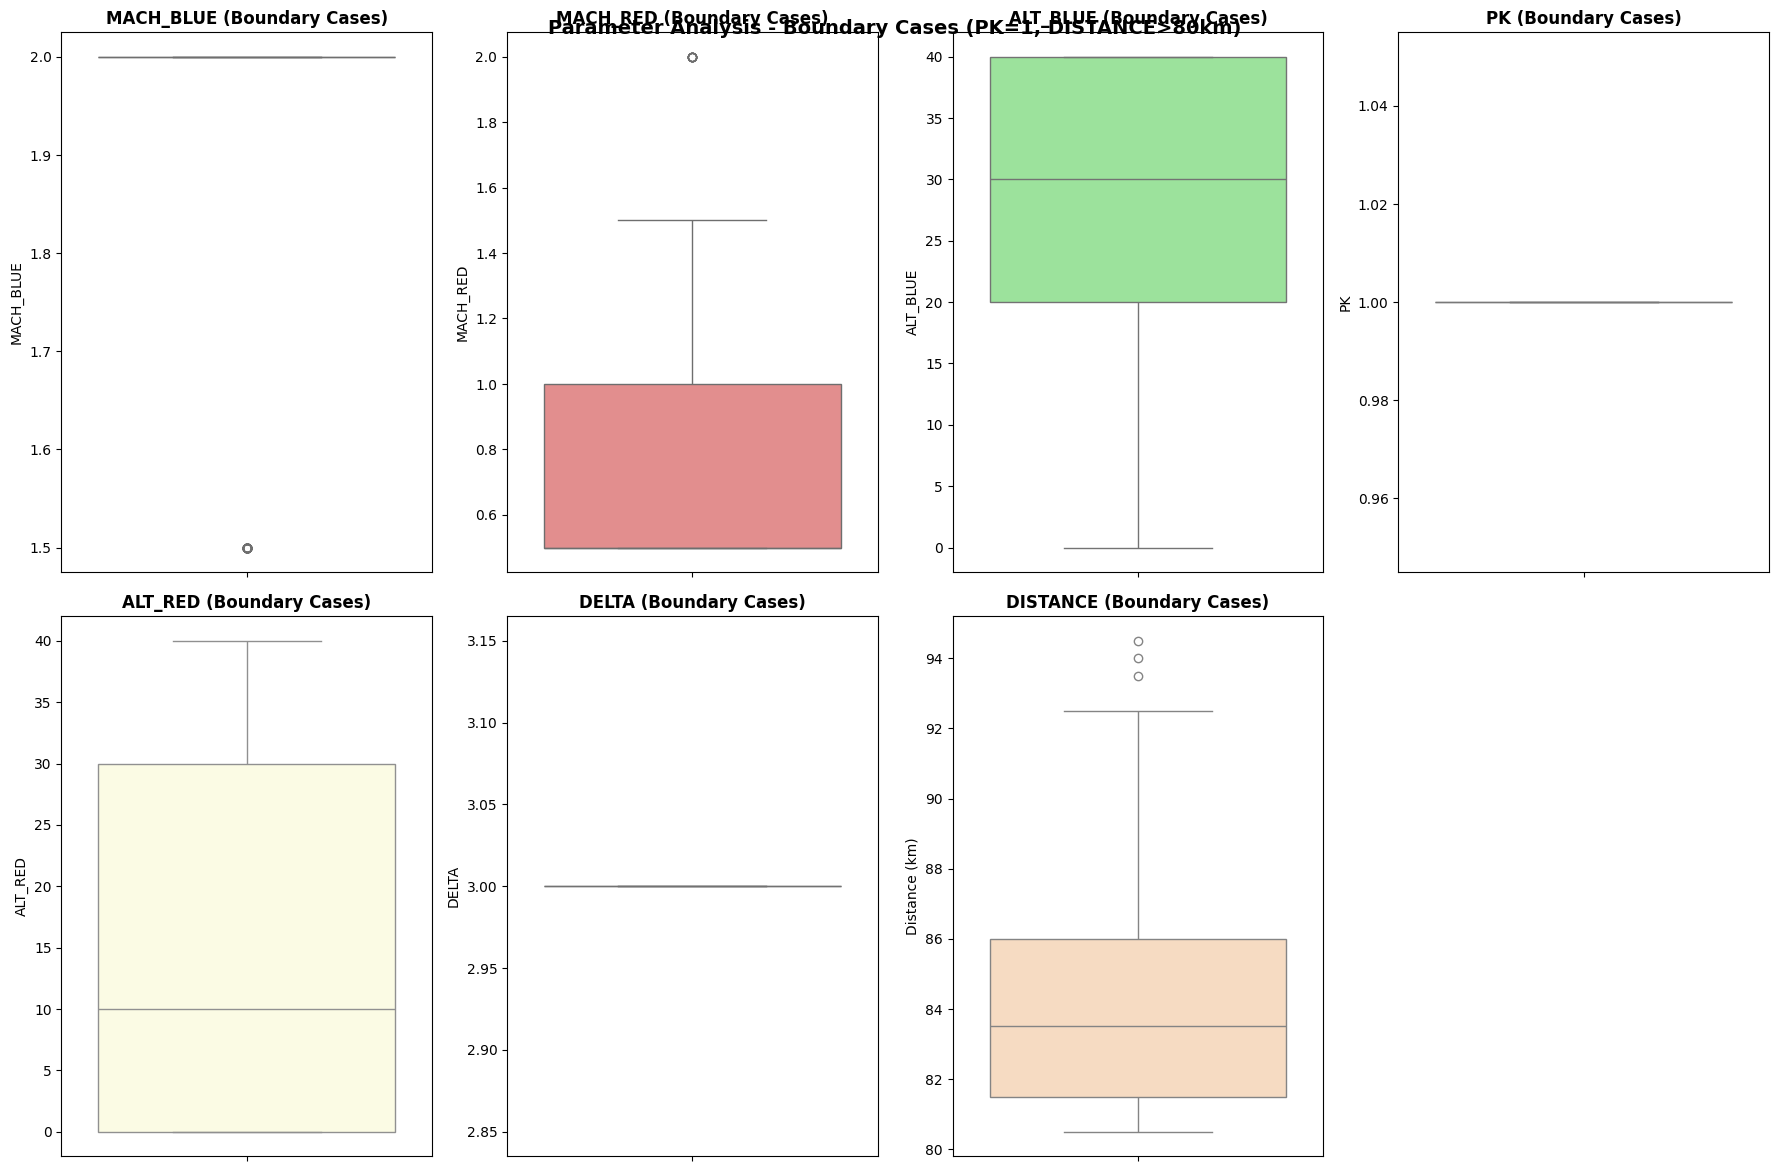

In [45]:
# Investigate Boundary Case Scenarios
# Filter for high PK values at large distances - these are "physics anomalies"
df_ax = df[(df["PK"]==1) & (df["DISTANCE"]>80)]

print(f"Number of boundary case records: {len(df_ax)}")
print(f"Percentage of total dataset: {len(df_ax)/len(df)*100:.2f}%")

# Analyze parameter distributions in boundary cases
fig, axes = plt.subplots(2, 4, figsize=(18, 12))

sns.boxplot(df_ax["MACH_BLUE"], ax=axes[0,0], color='skyblue')
axes[0,0].set_title('MACH_BLUE (Boundary Cases)', fontweight='bold')

sns.boxplot(df_ax["MACH_RED"], ax=axes[0,1], color='lightcoral')
axes[0,1].set_title('MACH_RED (Boundary Cases)', fontweight='bold')

sns.boxplot(df_ax["ALT_BLUE"], ax=axes[0,2], color='lightgreen')
axes[0,2].set_title('ALT_BLUE (Boundary Cases)', fontweight='bold')

sns.boxplot(df_ax["ALT_RED"], ax=axes[1,0], color='lightyellow')
axes[1,0].set_title('ALT_RED (Boundary Cases)', fontweight='bold')



sns.boxplot(df_ax["DELTA"], ax=axes[1,1], color='plum')
plt.tight_layout()

axes[1,1].set_title('DELTA (Boundary Cases)', fontweight='bold')
plt.suptitle('Parameter Analysis - Boundary Cases (PK=1, DISTANCE>80km)', fontsize=14, fontweight='bold')



sns.boxplot(df_ax["DISTANCE"], ax=axes[1,2], color='peachpuff')
fig.delaxes(axes[1,3])

axes[1,2].set_title('DISTANCE (Boundary Cases)', fontweight='bold')# Hide the empty subplot

axes[1,2].set_ylabel('Distance (km)')

axes[0,3].set_title('PK (Boundary Cases)', fontweight='bold')
sns.boxplot(df_ax["PK"], ax=axes[0,3], color='lightblue')

In [48]:
# Detailed Statistical Summary of Boundary Cases



print("STATISTICAL SUMMARY: BOUNDARY CASES (PK=1, DISTANCE>80km)")
print("="*70)
print("\n" + "="*70)
df_ax.describe()

STATISTICAL SUMMARY: BOUNDARY CASES (PK=1, DISTANCE>80km)



,MACH_BLUE,MACH_RED,ALT_BLUE,ALT_RED,DELTA,DISTANCE,PK
count,481.000000,481.000000,481.000000,481.000000,481.0,481.000000,481.0
mean,1.957380,0.798337,26.153846,16.070686,3.0,84.051975,1.0
std,0.139764,0.380347,13.116832,14.103309,0.0,2.944168,0.0
min,1.500000,0.500000,0.000000,0.000000,3.0,80.500000,1.0
25%,2.000000,0.500000,20.000000,0.000000,3.0,81.500000,1.0
50%,2.000000,0.500000,30.000000,10.000000,3.0,83.500000,1.0
75%,2.000000,1.000000,40.000000,30.000000,3.0,86.000000,1.0
max,2.000000,2.000000,40.000000,40.000000,3.0,94.500000,1.0
